In [1]:
import numpy as np

# 1. 创建形状为 3x4 的随机矩阵 X，元素服从标准正态分布
np.random.seed(42)  # 固定随机种子，结果可复现
X = np.random.randn(3, 4)

# 2. 创建形状为 4x2 的全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 计算矩阵乘法 Z = X @ Y
Z = X @ Y

# 4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素
print("Z 的第一行第二列元素:", Z[0, 1])
print("Z 的第二行所有元素:", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数
frob_norm = np.linalg.norm(Z, 'fro')
print("Z 的 Frobenius 范数:", frob_norm)

Z 的第一行第二列元素: 2.5291682463487657
Z 的第二行所有元素: [1.87835721 1.87835721]
Z 的 Frobenius 范数: 4.616873319476864


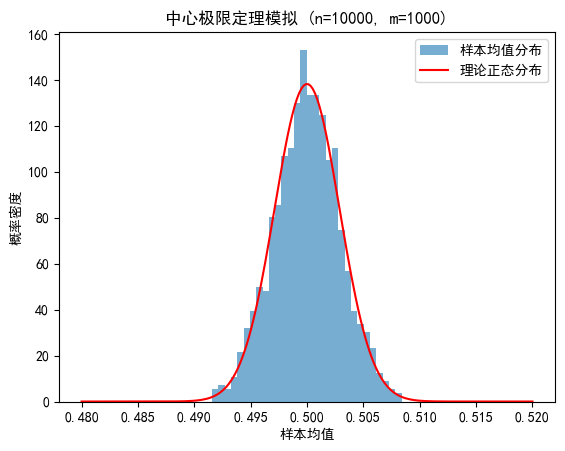

样本均值的实际方差: 0.000008
理论方差: 0.000008


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ===== 添加以下两行，让 Matplotlib 支持中文显示 =====
plt.rcParams['font.sans-serif'] = ['SimHei']        # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False          # 正常显示负号
# ====================================================

# 参数设置
n = 10000      # 每次抽取的样本量
m = 1000       # 重复次数

# 生成 m 个样本均值
means = []
for _ in range(m):
    sample = np.random.uniform(0, 1, n)
    means.append(np.mean(sample))

means = np.array(means)

# 理论：均匀分布 U(0,1) 的均值为 0.5，方差为 1/12
# 样本均值的理论方差 = (1/12) / n
theoretical_var = (1/12) / n
theoretical_std = np.sqrt(theoretical_var)

# 绘制直方图
plt.hist(means, bins=30, density=True, alpha=0.6, label='样本均值分布')

# 叠加理论正态分布 N(0.5, theoretical_var)
x = np.linspace(0.48, 0.52, 200)
plt.plot(x, norm.pdf(x, 0.5, theoretical_std), 'r-', label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.legend()
plt.title('中心极限定理模拟 (n=10000, m=1000)')
plt.show()

# 计算实际方差
actual_var = np.var(means)
print(f"样本均值的实际方差: {actual_var:.6f}")
print(f"理论方差: {theoretical_var:.6f}")

In [8]:
import torch

# 前向计算定义
def forward(x, w1, w2):
    a = x * w1
    b = a + w2
    L = b ** 2
    return L

# 给定参数
x = 2.0
w1 = 1.5
w2 = 0.5

# 手动梯度计算（链式法则）
# L = b^2, b = a + w2, a = x * w1
# dL/db = 2b, db/da = 1, db/dw2 = 1, da/dw1 = x
b = x * w1 + w2      # = 2*1.5+0.5=3.5
dL_db = 2 * b        # = 7.0
# 梯度对 w1
dL_dw1 = dL_db * 1 * x   # 7.0 * 2 = 14.0
# 梯度对 w2
dL_dw2 = dL_db * 1       # 7.0

print("手动梯度: dL/dw1 =", dL_dw1, ", dL/dw2 =", dL_dw2)

# 使用 PyTorch 自动微分验证
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
L = forward(x_t, w1_t, w2_t)
L.backward()
print("PyTorch 梯度: dL/dw1 =", w1_t.grad.item(), ", dL/dw2 =", w2_t.grad.item())

手动梯度: dL/dw1 = 14.0 , dL/dw2 = 7.0
PyTorch 梯度: dL/dw1 = 14.0 , dL/dw2 = 7.0


In [4]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载数据（digits 数据集是 MNIST 的子集，8x8 图像）
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)  # 展平为 64 维向量
y = digits.target.reshape(-1, 1)

# one-hot 编码
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Softmax 函数
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))  # 数值稳定
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    n = y_pred.shape[0]
    return -np.sum(y_true * np.log(y_pred + 1e-8)) / n

# 训练参数
n_features = X_train.shape[1]
n_classes = y_train.shape[1]
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

# 超参数
lr = 0.1
batch_size = 32
epochs = 50
n_samples = X_train.shape[0]

# 训练
for epoch in range(epochs):
    # 小批量 SGD
    indices = np.random.permutation(n_samples)
    for i in range(0, n_samples, batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train[batch_idx]
        
        # 前向
        logits = X_batch @ W + b
        y_pred = softmax(logits)
        loss = cross_entropy_loss(y_pred, y_batch)
        
        # 反向传播（梯度）
        grad_logits = y_pred - y_batch   # (batch_size, n_classes)
        grad_W = X_batch.T @ grad_logits / batch_size
        grad_b = np.mean(grad_logits, axis=0, keepdims=True)
        
        # 更新参数
        W -= lr * grad_W
        b -= lr * grad_b
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

# 测试
logits_test = X_test @ W + b
y_pred_test = softmax(logits_test)
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)
accuracy = np.mean(y_pred_labels == y_true_labels)
print(f"测试集准确率: {accuracy:.4f}")

Epoch 10, Loss: 0.0868
Epoch 20, Loss: 0.0004
Epoch 30, Loss: 0.0759
Epoch 40, Loss: 0.0000
Epoch 50, Loss: 0.0000
测试集准确率: 0.9667


Iter 200, loss = 0.0200
Iter 400, loss = 0.0133
Iter 600, loss = 0.0107
Iter 800, loss = 0.0093
Iter 1000, loss = 0.0083
测试集准确率: 1.0000


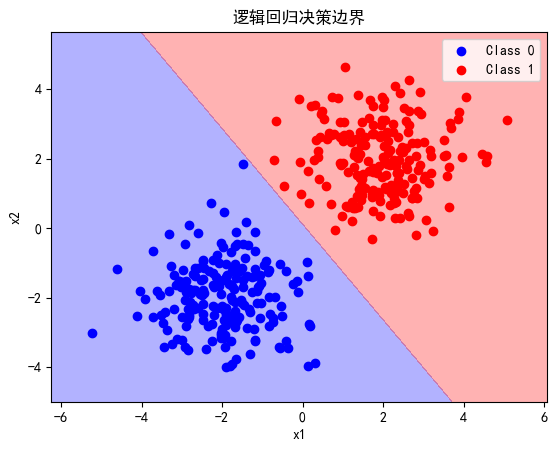

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ===== 添加以下两行，让 Matplotlib 支持中文显示 =====
plt.rcParams['font.sans-serif'] = ['SimHei']        # 使用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False          # 正常显示负号
# ====================================================

# 生成线性可分数据
np.random.seed(42)
n_samples = 200
# 类别 0
X0 = np.random.randn(n_samples, 2) + np.array([-2, -2])
y0 = np.zeros(n_samples)
# 类别 1
X1 = np.random.randn(n_samples, 2) + np.array([2, 2])
y1 = np.ones(n_samples)

X = np.vstack([X0, X1])
y = np.hstack([y0, y1])

# 划分训练/测试（简单起见，前 300 训练，后 100 测试）
X_train, X_test = X[:300], X[300:]
y_train, y_test = y[:300], y[300:]

# Sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失
def binary_cross_entropy(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

# 初始化参数
w = np.random.randn(2)
b = 0.0
lr = 0.1
iterations = 1000

# 梯度下降
for i in range(iterations):
    # 前向
    logits = X_train @ w + b
    y_pred = sigmoid(logits)
    loss = binary_cross_entropy(y_train, y_pred)
    
    # 梯度
    grad_w = X_train.T @ (y_pred - y_train) / len(y_train)
    grad_b = np.mean(y_pred - y_train)
    
    # 更新
    w -= lr * grad_w
    b -= lr * grad_b
    
    if (i+1) % 200 == 0:
        print(f"Iter {i+1}, loss = {loss:.4f}")

# 测试准确率
y_test_pred = sigmoid(X_test @ w + b) >= 0.5
accuracy = np.mean(y_test_pred == y_test)
print(f"测试集准确率: {accuracy:.4f}")

# 绘制决策边界
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ w + b)
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
plt.scatter(X0[:,0], X0[:,1], c='blue', label='Class 0')
plt.scatter(X1[:,0], X1[:,1], c='red', label='Class 1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('逻辑回归决策边界')
plt.show()

In [6]:
!pip install torch

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.5/114.6 MB 1.9 MB/s eta 0:00:59
    --------------------------------------- 1.8/114.6 MB 4.0 MB/s eta 0:00:29
    --------------------------------------- 2.1/114.6 MB 3.3 MB/s eta 0:00:35
    --------------------------------------- 2.4/114.6 MB 2.6 MB/s eta 0:00:44
    --------------------------------------- 2.4/114.6 MB 2.6 MB/s eta 0:00:44
   - -------------------------------------- 2.9/114.6 MB 2.1 MB/s eta 0:00:53
   - -------------------------------------- 2.9/114.6 MB 2.1 MB/s eta 0:00:53
   - -------------------------------------- 3.1/114.6 MB 1.9 MB/s eta 0:00:58
   - -------------------------------------- 3.4/114.6 MB 1.8 MB/s eta 0:01:03
   - -------------------------------------- 3.7/114.6 MB 1.7 MB/s eta 0:01:07
   - --